# 03 — Backtest: cointegration mean-reversion

The robust, tradeable edge is the **cointegration mean-reversion**. This is a ProbI strategy that trades the spread-z directly; the geopolitical events are an **overlay** on the PnL chart, not triggers.

**Signal.** Trailing-window z-score of the dollar spread:
$$z_t = \frac{s_t - \mu_{t}^{(L)}}{\sigma_{t}^{(L)}}, \quad \mu,\sigma \text{ over the prior } L \text{ days (shifted, no lookahead).}$$

**Rule.**
- Enter **long spread** (long Brent / short WTI) when `z ≤ −ENTRY`; enter **short spread** when `z ≥ +ENTRY`.
- Exit when `|z| ≤ EXIT` (reverted) or hard-stop when `|z| ≥ STOP` (regime break).
- One position at a time; next-bar execution (signal at close t, position from t+1) to avoid lookahead.

Parameters are fixed *a priori* not tuned.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", palette="deep")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
df = pd.read_csv(REPO / "data" / "processed" / "spread.csv", parse_dates=["date"]).set_index("date").sort_index()

# Strategy parameters (fixed a priori, not tuned)
L = 60          # trailing window for the z-score (~1 quarter, ~2.5x the 24d half-life)
ENTRY = 2.0
EXIT = 0.5
STOP = 3.5
OOS_START = "2019-01-01"
TRADING_DAYS = 252

EVENTS = {
    "Aramco 2019": "2019-09-16", "Soleimani 2020": "2020-01-03",
    "Houthi 2024": "2024-01-19", "Epic Fury 2026": "2026-02-28",
    "Hormuz 2026": "2026-03-04",
}
print(f"{len(df):,} rows {df.index.min().date()} -> {df.index.max().date()}")

9,734 rows 1987-05-20 -> 2026-06-01


## Signal — trailing z-score (no lookahead)

The rolling mean/std use the prior `L` days and are `shift(1)`-ed so z at day *t* uses only information available at the close of *t−1*. 

In [2]:
s = df["spread"]
mu = s.rolling(L).mean().shift(1)
sd = s.rolling(L).std(ddof=1).shift(1)
df["z"] = (s - mu) / sd
df = df.dropna(subset=["z"]).copy()
print(f"z defined on {len(df):,} rows from {df.index.min().date()}")
df["z"].describe().round(2)

z defined on 9,674 rows from 1987-08-14


count    9674.00
mean        0.06
std         1.30
min        -6.40
25%        -0.81
50%         0.07
75%         0.91
max         9.63
Name: z, dtype: float64

In [3]:
def run_positions(zv: np.ndarray) -> np.ndarray:
    """Target position decided at each day's close (pre-shift). +1 = long spread."""
    pos = np.zeros(len(zv))
    cur = 0
    for i, zi in enumerate(zv):
        if cur == 0:
            if zi <= -ENTRY:
                cur = +1
            elif zi >= ENTRY:
                cur = -1
        else:
            if abs(zi) <= EXIT or abs(zi) >= STOP:
                cur = 0
        pos[i] = cur
    return pos


df["pos_signal"] = run_positions(df["z"].values)
df["pos"] = df["pos_signal"].shift(1).fillna(0)   # next-bar execution
df["d_spread"] = df["spread"].diff()
df["pnl"] = df["pos"] * df["d_spread"]
df[["z", "pos", "pnl"]].tail()

,z,pos,pnl
date,,,
2026-05-26,-0.994364,0.0,-0.0
2026-05-27,-1.045536,0.0,-0.0
2026-05-28,-1.318599,0.0,-0.0
2026-05-29,-1.467876,0.0,-0.0
2026-06-01,-1.352591,0.0,0.0


## Performance — full sample, train, OOS

In [4]:
def trade_blocks(frame: pd.DataFrame) -> pd.DataFrame:
    """Group consecutive non-zero positions into discrete trades."""
    p = frame["pos"].values
    trades, start = [], None
    for i in range(len(p)):
        if p[i] != 0 and start is None:
            start = i
        if start is not None and (p[i] == 0 or i == len(p) - 1):
            end = i if p[i] == 0 else i + 1
            blk = frame.iloc[start:end]
            trades.append({"pnl": blk["pnl"].sum(), "days": len(blk)})
            start = None
    return pd.DataFrame(trades)


def metrics(frame: pd.DataFrame, label: str) -> dict:
    pnl = frame["pnl"]
    sharpe = (pnl.mean() / pnl.std(ddof=1)) * np.sqrt(TRADING_DAYS) if pnl.std() else np.nan
    eq = pnl.cumsum()
    max_dd = (eq - eq.cummax()).min()
    tr = trade_blocks(frame)
    return {
        "segment": label, "days": len(frame), "trades": len(tr),
        "hit rate": round((tr["pnl"] > 0).mean(), 2) if len(tr) else np.nan,
        "total PnL ($)": round(pnl.sum(), 1),
        "mean/trade ($)": round(tr["pnl"].mean(), 2) if len(tr) else np.nan,
        "avg hold (d)": round(tr["days"].mean(), 1) if len(tr) else np.nan,
        "ann. Sharpe": round(sharpe, 2), "max DD ($)": round(max_dd, 1),
    }


oos = df[df.index >= OOS_START]
train = df[df.index < OOS_START]
perf = pd.DataFrame([
    metrics(df, "Full 1987-2026"),
    metrics(train, "Train 1987-2018"),
    metrics(oos, "OOS 2019-2026"),
]).set_index("segment")
perf

,days,trades,hit rate,total PnL ($),mean/trade ($),avg hold (d),ann. Sharpe,max DD ($)
segment,,,,,,,,
Full 1987-2026,9674,354,0.81,395.7,1.12,8.5,1.00,-26.0
Train 1987-2018,7848,291,0.81,307.3,1.06,8.3,0.99,-23.9
OOS 2019-2026,1826,63,0.83,88.4,1.40,9.4,1.02,-26.0


## Benchmark — naive always-long spread

In [5]:
def benchmark(frame: pd.DataFrame) -> dict:
    pnl = frame["d_spread"].dropna()
    sh = (pnl.mean() / pnl.std(ddof=1)) * np.sqrt(TRADING_DAYS) if pnl.std() else np.nan
    eq = pnl.cumsum()
    return {"ann. Sharpe": round(sh, 2), "total PnL ($)": round(pnl.sum(), 1),
            "max DD ($)": round((eq - eq.cummax()).min(), 1)}


pd.DataFrame({
    "strategy (OOS)": {k: metrics(oos, "OOS")[k] for k in ["ann. Sharpe", "total PnL ($)", "max DD ($)"]},
    "always-long (OOS)": benchmark(oos),
}).T

,ann. Sharpe,total PnL ($),max DD ($)
strategy (OOS),1.02,88.4,-26.0
always-long (OOS),-0.02,-3.1,-24.2


## Out-of-sample equity curve with event overlay

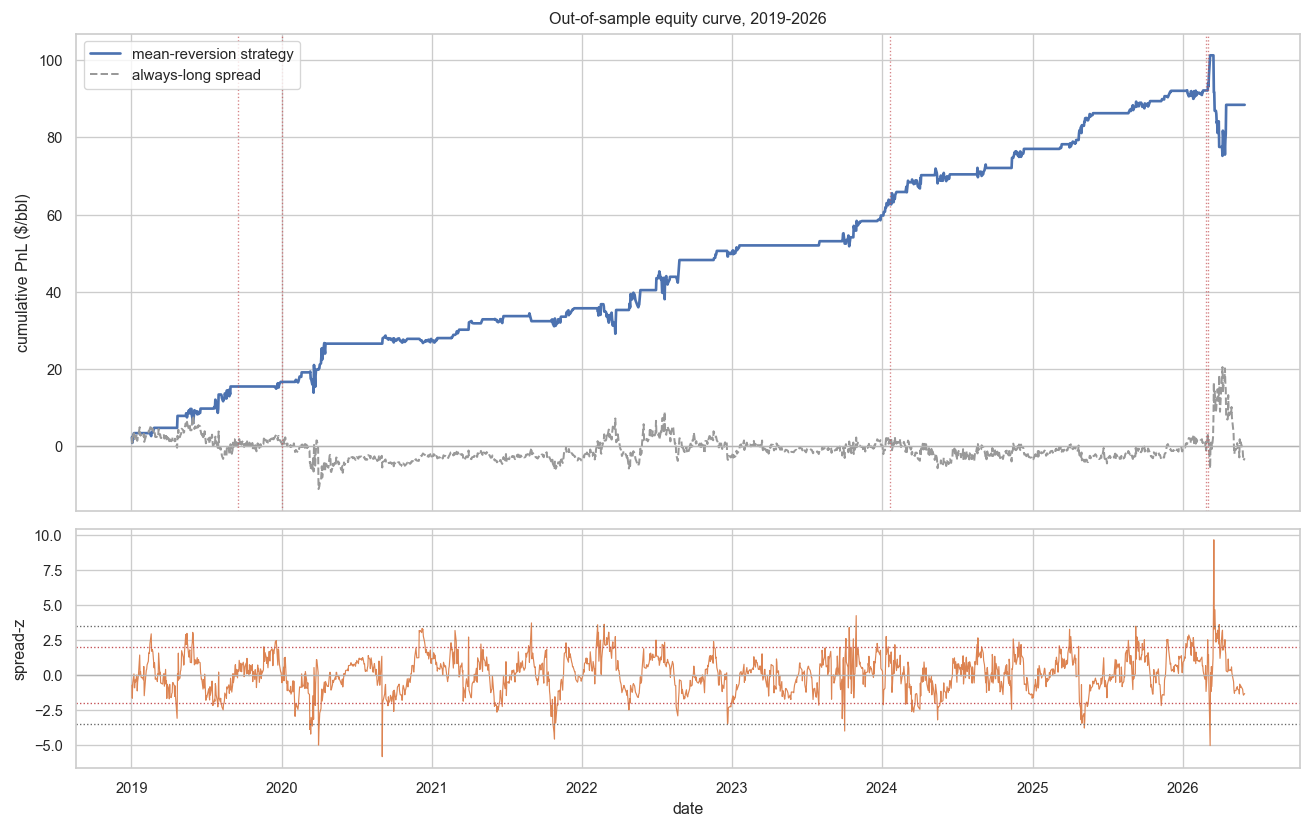

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})

eq = oos["pnl"].cumsum()
bench = oos["d_spread"].cumsum()
ax1.plot(eq.index, eq, color="C0", lw=1.6, label="mean-reversion strategy")
ax1.plot(bench.index, bench, color="0.6", lw=1.2, ls="--", label="always-long spread")
ax1.axhline(0, color="0.7", lw=0.8)
ax1.set_ylabel("cumulative PnL ($/bbl)")
ax1.set_title("Out-of-sample equity curve, 2019-2026")
for name, d in EVENTS.items():
    ts = pd.Timestamp(d)
    if ts >= eq.index.min():
        ax1.axvline(ts, color="C3", ls=":", lw=0.8, alpha=0.7)
ax1.legend(loc="upper left", fontsize=9)

ax2.plot(oos.index, oos["z"], color="C1", lw=0.7)
for lvl, c in [(ENTRY, "C3"), (-ENTRY, "C3"), (STOP, "0.4"), (-STOP, "0.4")]:
    ax2.axhline(lvl, color=c, ls=":", lw=0.8)
ax2.axhline(0, color="0.7", lw=0.8)
ax2.set_ylabel("spread-z"); ax2.set_xlabel("date")
fig.tight_layout()
fig.savefig(REPO / "figures" / "fig_backtest_oos.png", bbox_inches="tight")
plt.show()

## Headline backtest numbers

In [7]:
m = metrics(oos, "OOS")
summary = pd.Series({
    "OOS window": f"{oos.index.min().date()} -> {oos.index.max().date()}",
    "OOS trades": m["trades"], "OOS hit rate": m["hit rate"],
    "OOS ann. Sharpe": m["ann. Sharpe"], "OOS max drawdown ($)": m["max DD ($)"],
    "OOS avg hold (days)": m["avg hold (d)"],
    "Benchmark OOS Sharpe": benchmark(oos)["ann. Sharpe"],
})
summary.to_frame("value")

,value
OOS window,2019-01-02 -> 2026-06-01
OOS trades,63
OOS hit rate,0.83
OOS ann. Sharpe,1.02
OOS max drawdown ($),-26.0
OOS avg hold (days),9.4
Benchmark OOS Sharpe,-0.02


## Statistical significance — is the edge luck?

Two non-parametric checks on the OOS strategy. **(1) Block bootstrap** (20-day blocks, 5,000 resamples) preserves serial correlation and gives a 95% CI for the Sharpe. **(2) Permutation test** (2,000 trials) shuffles the *z*-score series and re-runs the rule end-to-end: if the edge were a random-walk artefact, scrambling the signal ordering would not destroy it. A low *p* means the *ordering* of the signal carries the PnL.

In [8]:
def _sharpe(p):
    p = pd.Series(p).dropna()
    return (p.mean() / p.std(ddof=1)) * np.sqrt(TRADING_DAYS) if p.std(ddof=1) > 0 else np.nan

rng = np.random.default_rng(42)
S0 = _sharpe(oos["pnl"])

# (1) Block bootstrap (block=20d, 5,000 resamples)
pnl = oos["pnl"].fillna(0).to_numpy()
n, B, REPS = len(pnl), 20, 5000
nblk = int(np.ceil(n / B))
boot = np.empty(REPS)
for r in range(REPS):
    st = rng.integers(0, n - B + 1, size=nblk)
    boot[r] = _sharpe(np.concatenate([pnl[t:t + B] for t in st])[:n])
ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])

# (2) Permutation test (shuffle z, re-run rule, 2,000 trials)
zv, dv = oos["z"].to_numpy(), oos["d_spread"].to_numpy()
PERM = 2000
perm = np.empty(PERM)
for r in range(PERM):
    pos_p = pd.Series(run_positions(rng.permutation(zv))).shift(1).fillna(0).to_numpy()
    perm[r] = _sharpe(pos_p * dv)
p_val = (np.sum(perm >= S0) + 1) / (PERM + 1)

print(f"OOS Sharpe                : {S0:.2f}")
print(f"Block-bootstrap 95% CI    : [{ci_lo:.2f}, {ci_hi:.2f}]  (block=20d, 5,000 resamples)")
print(f"Permutation mean Sharpe   : {perm.mean():+.3f}")
print(f"Permutation p-value       : {p_val:.4f}  (2,000 z-shuffles)")

OOS Sharpe                : 1.02
Block-bootstrap 95% CI    : [0.33, 1.65]  (block=20d, 5,000 resamples)
Permutation mean Sharpe   : -0.002
Permutation p-value       : 0.0005  (2,000 z-shuffles)
